<a href="https://colab.research.google.com/github/DrAyesha91/Nasscom-fdp-/blob/main/ericsson_patent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Ericsson Patent Data — End-to-End ML Pipeline

> **Dataset:** Ericsson Innovation Timeline & Patent Evolution  
> **Task:** Predict `target_patent_count_next_quarter` (regression)  
> **Source:** [Kaggle – adamvakar/ericsson-innovation-timeline-patent-evolution](https://www.kaggle.com/datasets/adamvakar/ericsson-innovation-timeline-patent-evolution)

---

## 🗺️ Notebook Roadmap

| Step | Section |
|------|---------|
| 1 | Setup & Imports |
| 2 | Load the Raw Dataset |
| 3 | Exploratory Data Analysis (EDA) |
| 4 | Data Cleaning |
| 5 | Feature Engineering & Encoding |
| 6 | Train / Test Split |
| 7 | Model Training |
| 8 | Model Evaluation |
| 9 | Prediction & Interpretation |

---

> 💡 **Learning Tip:** Run every cell top-to-bottom.  
> Each section builds on the previous one — skipping ahead will cause errors.


---
## 🔧 Section 1 — Setup & Imports

We first install any missing packages, then import every library we'll use in one place.  
This makes it easy to track dependencies at a glance.


In [1]:
# Install required packages (only runs if they aren't already installed)
# Uncomment the line below if you're running this for the first time
# !pip install pandas numpy matplotlib seaborn scikit-learn xgboost kaggle --quiet


In [2]:
# ── Core libraries ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 110

# ── Machine Learning ─────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
from xgboost import XGBRegressor

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


In [ ]:
import sys
print(sys.executable)

/usr/bin/python3


In [ ]:
import sys
!{sys.executable} -m pip install xgboost --quiet

---
## 📂 Section 2 — Load the Raw Dataset

### Why keep a raw copy?
We preserve the original data in `df_raw` throughout the notebook.  
This is a best practice:
- You can always compare cleaned data against the original.
- You can restart cleaning from scratch without re-downloading.
- It makes debugging much easier.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

# List contents of your Google Drive 'My Drive' folder
print('Listing contents of /content/drive/My Drive:')
for root, dirs, files in os.walk('/content/drive/My Drive'):
    for name in files:
        if 'ericsson_dataset.csv' in name:
            print(os.path.join(root, name))
    for name in dirs:
        pass # Optionally print directories too, but focusing on the file for now

print('\nOnce you find the correct path, update the DATA_PATH variable in the previous cell.')

Listing contents of /content/drive/My Drive:
/content/drive/My Drive/NASSCOM FDP VEDIC/patent_project/ericsson_dataset.csv

Once you find the correct path, update the DATA_PATH variable in the previous cell.


In [5]:
# ── Option A: Download from Kaggle ──────────────────────────────────────────
# (Run this block only once; requires a kaggle.json API key)
# (Run this block only once; requires a kaggle.json API key)

# import os, zipfile
# os.system("python -m kaggle datasets download -d adamvakar/ericsson-innovation-timeline-patent-evolution -p .")
# with zipfile.ZipFile("ericsson-innovation-timeline-patent-evolution.zip", "r") as z:
#     z.extractall(".")

# ── Option B: Load from local file (recommended after first download) ─────────
DATA_PATH = "/content/drive/My Drive/NASSCOM FDP VEDIC/patent_project/ericsson_dataset.csv"   # ← updated path

df_raw = pd.read_csv(DATA_PATH)

print(f"✅ Dataset loaded:  {df_raw.shape[0]:,} rows  ×  {df_raw.shape[1]} columns")


✅ Dataset loaded:  30,118 rows  ×  55 columns


In [6]:
# Quick peek at the first few rows
df_raw.head()


,patent_id,patent_type,patent_date,patent_title,year,quarter,month,day_of_week,day_of_year,quarter_end,...,patent_count_lag4,patent_count_roll4_mean,patent_count_roll8_mean,patent_count_qoq,patent_count_yoy,target_patent_count_current,target_patent_count_next_quarter,years_since_first_patent,patent_seq_global,year_patent_count
0,3934093,utility,1976-01-20,Transit exchange for asynchronous data with un...,1976,1,1,1,20,1976-03-31,...,324.0,347.75,337.375,0.023873,0.074324,10,5.0,0,1,36
1,3936612,utility,1976-02-03,Control and holding circuit for relay matrices,1976,1,2,1,34,1976-03-31,...,324.0,347.75,337.375,0.023873,0.074324,10,5.0,0,3,36
2,3936781,utility,1976-02-03,Selecting device for crossbar switches,1976,1,2,1,34,1976-03-31,...,324.0,347.75,337.375,0.023873,0.074324,10,5.0,0,2,36
3,3938025,utility,1976-02-10,DC to DC converter for producing two individua...,1976,1,2,1,41,1976-03-31,...,324.0,347.75,337.375,0.023873,0.074324,10,5.0,0,5,36
4,3938040,utility,1976-02-10,Apparatus for measuring a signal voltage inclu...,1976,1,2,1,41,1976-03-31,...,324.0,347.75,337.375,0.023873,0.074324,10,5.0,0,4,36


In [7]:
# Column names at a glance
print("Columns:", df_raw.columns.tolist())


Columns: ['patent_id', 'patent_type', 'patent_date', 'patent_title', 'year', 'quarter', 'month', 'day_of_week', 'day_of_year', 'quarter_end', 'title_len_chars', 'title_len_words', 'title_has_number', 'title_has_acronym', 'kw_5g', 'kw_ai_ml', 'kw_cloud_edge', 'kw_security', 'kw_iot', 'kw_network', 'kw_energy', 'kw_antenna', 'kw_data', 'keyword_score', 'is_utility', 'is_design', 'is_other_type', 'tech_era', 'patent_count', 'patent_unique', 'utility_share', 'design_share', 'avg_title_words', 'avg_keyword_score', 'kw_5g_count', 'kw_ai_ml_count', 'kw_cloud_edge_count', 'kw_security_count', 'kw_iot_count', 'kw_network_count', 'kw_energy_count', 'kw_antenna_count', 'kw_data_count', 'patent_count_lag1', 'patent_count_lag2', 'patent_count_lag4', 'patent_count_roll4_mean', 'patent_count_roll8_mean', 'patent_count_qoq', 'patent_count_yoy', 'target_patent_count_current', 'target_patent_count_next_quarter', 'years_since_first_patent', 'patent_seq_global', 'year_patent_count']


In [8]:
# Data types for every column
df_raw.dtypes


,0
patent_id,object
patent_type,object
patent_date,object
patent_title,object
year,int64
quarter,int64
month,int64
day_of_week,int64
day_of_year,int64
quarter_end,object


---
## 🔍 Section 3 — Exploratory Data Analysis (EDA)

EDA is like a medical check-up for your dataset.  
We want to understand:
1. **Shape** — how many rows and columns?
2. **Missing values** — which columns have gaps?
3. **Duplicates** — are any rows repeated?
4. **Distributions** — what do numeric features look like?
5. **Categorical values** — what unique values exist?
6. **Target variable** — is it skewed or balanced?

> 🎓 EDA is **not** about cleaning yet — it's about *understanding*.


In [9]:
# ── 3.1 Shape & Basic Info ────────────────────────────────────────────────────
print("=" * 50)
print(f"  Rows    : {df_raw.shape[0]:,}")
print(f"  Columns : {df_raw.shape[1]}")
print("=" * 50)
df_raw.info()


  Rows    : 30,118
  Columns : 55
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30118 entries, 0 to 30117
Data columns (total 55 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   patent_id                         30118 non-null  object 
 1   patent_type                       30118 non-null  object 
 2   patent_date                       30118 non-null  object 
 3   patent_title                      30118 non-null  object 
 4   year                              30118 non-null  int64  
 5   quarter                           30118 non-null  int64  
 6   month                             30118 non-null  int64  
 7   day_of_week                       30118 non-null  int64  
 8   day_of_year                       30118 non-null  int64  
 9   quarter_end                       30118 non-null  object 
 10  title_len_chars                   30118 non-null  int64  
 11  title_len_words                  

In [10]:
# ── 3.2 Statistical Summary (numeric columns) ────────────────────────────────
df_raw.describe().T


,count,mean,std,min,25%,50%,75%,max
year,30118.0,2013.233382,8.851538,1976.00,2008.000000,2015.000000,2020.000000,2025.000000
quarter,30118.0,2.514510,1.101261,1.00,2.000000,3.000000,3.000000,4.000000
month,30118.0,6.546185,3.381182,1.00,4.000000,7.000000,9.000000,12.000000
day_of_week,30118.0,1.000000,0.000000,1.00,1.000000,1.000000,1.000000,1.000000
day_of_year,30118.0,183.744638,103.281235,1.00,95.000000,184.000000,271.000000,366.000000
title_len_chars,30118.0,64.396142,29.750263,4.00,44.000000,60.000000,81.000000,268.000000
title_len_words,30118.0,8.820473,4.383788,1.00,6.000000,8.000000,11.000000,39.000000
title_has_number,30118.0,0.018594,0.135087,0.00,0.000000,0.000000,0.000000,1.000000
title_has_acronym,30118.0,0.162129,0.368575,0.00,0.000000,0.000000,0.000000,1.000000
kw_5g,30118.0,0.007205,0.084577,0.00,0.000000,0.000000,0.000000,1.000000


In [11]:
# ── 3.3 Missing Value Analysis ────────────────────────────────────────────────
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print(missing_df.to_string() if not missing_df.empty else "✅ No missing values found!")


                                  Missing Count  Missing %
target_patent_count_next_quarter            408       1.35


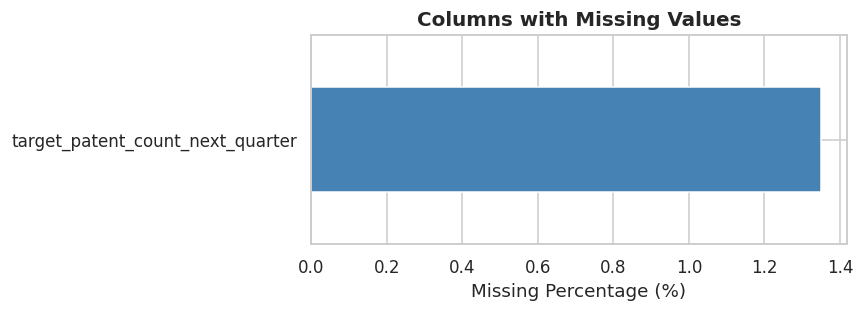

In [12]:
# Visualise missing values (if any)
if not missing_df.empty:
    fig, ax = plt.subplots(figsize=(8, max(3, len(missing_df) * 0.5)))
    missing_df['Missing %'].sort_values().plot(
        kind='barh', ax=ax, color='steelblue', edgecolor='white'
    )
    ax.set_xlabel('Missing Percentage (%)')
    ax.set_title('Columns with Missing Values', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No missing value chart needed.")


In [13]:
# ── 3.4 Duplicate Rows ────────────────────────────────────────────────────────
dup_count = df_raw.duplicated().sum()
print(f"Duplicate rows: {dup_count}")


Duplicate rows: 0


In [14]:
# ── 3.5 Categorical Column Inspection ────────────────────────────────────────
cat_cols = df_raw.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns: {cat_cols}\n")

for col in cat_cols:
    print(f"  [{col}]")
    print(df_raw[col].value_counts().to_string())
    print()


Streaming output truncated to the last 5000 lines.
Methods and systems for bootstrapping security key information using session initiation protocol                                                                                                                                                                                 1
Method and arrangement for deciding a security setting                                                                                                                                                                                                                           1
Method of retrieving information from a notifying node of SIP/IMS network to a watcher client                                                                                                                                                                                    1
Optimized reservation for multi-session and/or multi-unit types                                                             

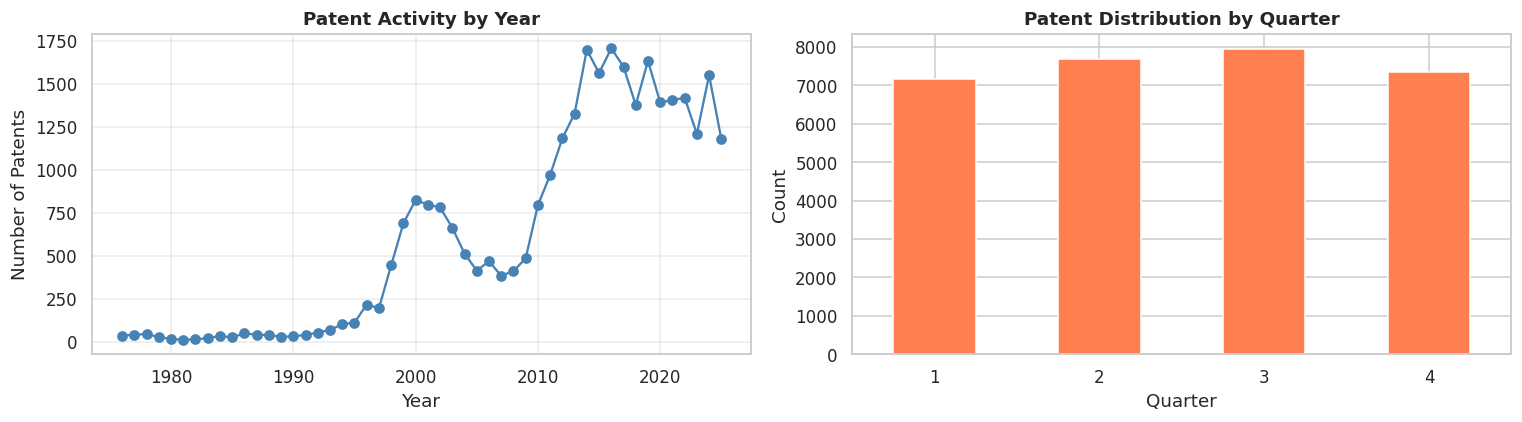

In [15]:
# ── 3.6 Patent Activity Over Time ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# By Year
year_counts = df_raw.groupby('year')['patent_id'].count()
axes[0].plot(year_counts.index, year_counts.values, marker='o', color='steelblue')
axes[0].set_title('Patent Activity by Year', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Patents')
axes[0].grid(True, alpha=0.4)

# By Quarter
df_raw['quarter'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='white'
)
axes[1].set_title('Patent Distribution by Quarter', fontweight='bold')
axes[1].set_xlabel('Quarter')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


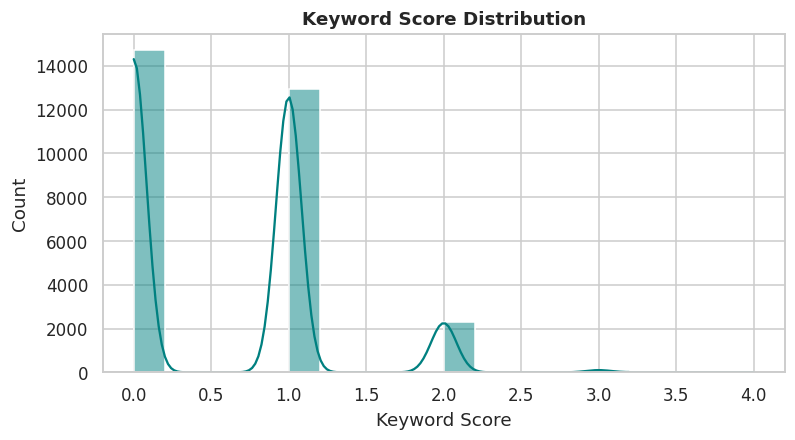

In [16]:
# ── 3.7 Keyword Score Distribution ────────────────────────────────────────────
plt.figure(figsize=(8, 4))
sns.histplot(df_raw['keyword_score'], bins=20, kde=True, color='teal')
plt.title('Keyword Score Distribution', fontweight='bold')
plt.xlabel('Keyword Score')
plt.show()


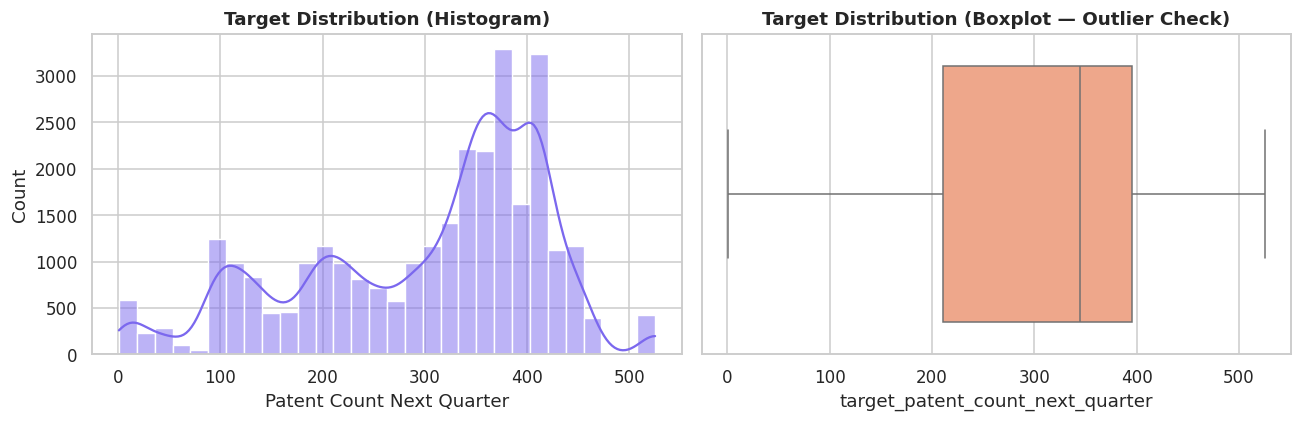

count    29710.000000
mean       300.642141
std        118.612862
min          1.000000
25%        211.000000
50%        345.000000
75%        395.000000
max        525.000000
Name: target_patent_count_next_quarter, dtype: float64


In [17]:
# ── 3.8 Target Variable Distribution ─────────────────────────────────────────
target = 'target_patent_count_next_quarter'

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df_raw[target].dropna(), bins=30, kde=True, color='mediumslateblue', ax=axes[0])
axes[0].set_title('Target Distribution (Histogram)', fontweight='bold')
axes[0].set_xlabel('Patent Count Next Quarter')

sns.boxplot(x=df_raw[target].dropna(), color='lightsalmon', ax=axes[1])
axes[1].set_title('Target Distribution (Boxplot — Outlier Check)', fontweight='bold')

plt.tight_layout()
plt.show()

print(df_raw[target].describe())


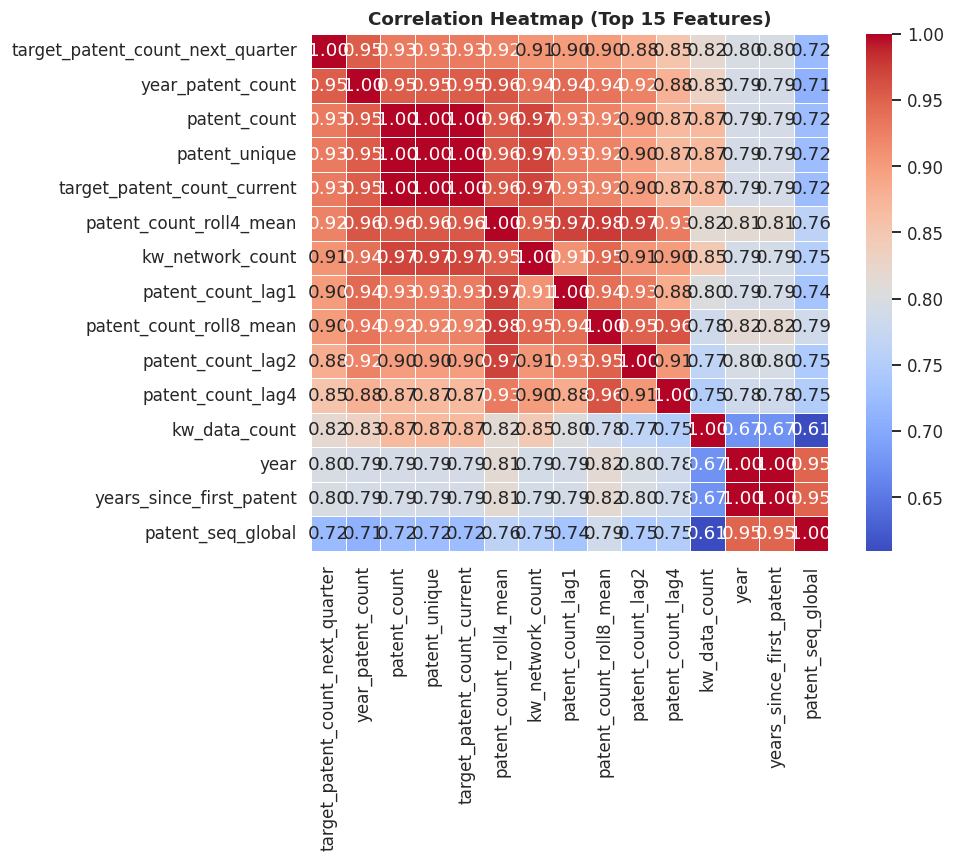

In [18]:
# ── 3.9 Correlation Heatmap (top numeric features) ────────────────────────────
numeric_cols = df_raw.select_dtypes(include='number').columns
corr = df_raw[numeric_cols].corr()

# Focus on features with highest correlation to target
top_corr = corr[target].abs().sort_values(ascending=False).head(15)
top_features = top_corr.index.tolist()

plt.figure(figsize=(10, 8))
sns.heatmap(
    df_raw[top_features].corr(),
    annot=True, fmt='.2f', cmap='coolwarm',
    linewidths=0.5, square=True
)
plt.title('Correlation Heatmap (Top 15 Features)', fontweight='bold')
plt.tight_layout()
plt.show()


---
## 🧹 Section 4 — Data Cleaning

We now create `df_clean` — a cleaned copy of `df_raw`.  

**Rule: Never modify `df_raw` directly.**  
This ensures we can always trace what changed and why.

### Cleaning steps we'll perform:
1. Fix the `patent_date` column dtype (string → datetime)
2. Drop rows where the **target** is missing (they can't be used for training)
3. Verify no duplicates remain
4. Confirm all dtypes are correct

> 💡 Always document *why* you remove or fix something.  
> Future you (and your team) will thank you.


In [19]:
# Start from a fresh copy — never mutate df_raw!
df_clean = df_raw.copy()

print(f"Starting shape: {df_clean.shape}")


Starting shape: (30118, 55)


In [20]:
# ── 4.1 Fix date column dtype ─────────────────────────────────────────────────
# 'patent_date' is stored as a string — convert it to proper datetime
df_clean['patent_date'] = pd.to_datetime(df_clean['patent_date'])

print("patent_date dtype after fix:", df_clean['patent_date'].dtype)


patent_date dtype after fix: datetime64[ns]


In [21]:
# ── 4.2 Handle missing target values ─────────────────────────────────────────
# WHY: The target 'target_patent_count_next_quarter' is NaN for the most
# recent quarter (there is no *future* quarter to predict into yet).
# These rows are NOT useful for supervised learning, so we drop them.

target = 'target_patent_count_next_quarter'

rows_before = len(df_clean)
df_clean = df_clean.dropna(subset=[target])
rows_after  = len(df_clean)

print(f"Rows removed (missing target): {rows_before - rows_after}")
print(f"Remaining rows: {rows_after:,}")


Rows removed (missing target): 408
Remaining rows: 29,710


In [22]:
# ── 4.3 Verify no duplicate rows ─────────────────────────────────────────────
dup_after = df_clean.duplicated().sum()
print(f"Duplicate rows after cleaning: {dup_after}")


Duplicate rows after cleaning: 0


In [23]:
# ── 4.4 Verify no remaining missing values ───────────────────────────────────
remaining_nulls = df_clean.isnull().sum()
remaining_nulls = remaining_nulls[remaining_nulls > 0]

if remaining_nulls.empty:
    print("✅ No missing values remaining!")
else:
    print("⚠️  Columns still with missing values:")
    print(remaining_nulls)


✅ No missing values remaining!


In [24]:
# ── 4.5 Cleaning Summary ──────────────────────────────────────────────────────
print("=" * 50)
print("         DATA CLEANING SUMMARY")
print("=" * 50)
print(f"  Raw dataset rows    : {df_raw.shape[0]:,}")
print(f"  Cleaned dataset rows: {df_clean.shape[0]:,}")
print(f"  Rows removed        : {df_raw.shape[0] - df_clean.shape[0]}")
print(f"  Reason for removal  : Missing target value (last quarter)")
print(f"  Columns unchanged   : {df_clean.shape[1]}")
print("=" * 50)


         DATA CLEANING SUMMARY
  Raw dataset rows    : 30,118
  Cleaned dataset rows: 29,710
  Rows removed        : 408
  Reason for removal  : Missing target value (last quarter)
  Columns unchanged   : 55


In [25]:
# ── 4.6 Side-by-side comparison: Raw vs Cleaned ──────────────────────────────
comparison = pd.DataFrame({
    'Metric': ['Rows', 'Columns', 'Missing Values', 'Duplicates'],
    'Raw Dataset': [
        df_raw.shape[0],
        df_raw.shape[1],
        df_raw.isnull().sum().sum(),
        df_raw.duplicated().sum()
    ],
    'Cleaned Dataset': [
        df_clean.shape[0],
        df_clean.shape[1],
        df_clean.isnull().sum().sum(),
        df_clean.duplicated().sum()
    ]
})

print(comparison.to_string(index=False))


        Metric  Raw Dataset  Cleaned Dataset
          Rows        30118            29710
       Columns           55               55
Missing Values          408                0
    Duplicates            0                0


In [26]:
# ── 4.7 Save both datasets locally ───────────────────────────────────────────
df_raw.to_csv("ericsson_patents_RAW.csv", index=False)
df_clean.to_csv("ericsson_patents_CLEANED.csv", index=False)

print("✅ Saved: ericsson_patents_RAW.csv")
print("✅ Saved: ericsson_patents_CLEANED.csv")


✅ Saved: ericsson_patents_RAW.csv
✅ Saved: ericsson_patents_CLEANED.csv


---
## ⚙️ Section 5 — Feature Engineering & Encoding

Machine learning models can only work with **numbers**.  
Categorical columns like `patent_type` and `tech_era` must be converted.

We'll use **One-Hot Encoding** (OHE):
- Converts each category into a binary (0 or 1) column.
- Avoids implying any ordinal relationship between categories.
- `drop_first=True` removes one redundant column per feature to prevent multicollinearity.

### Features we select:
- **Temporal**: `year`, `quarter`
- **Text-based**: `title_len_words`, `keyword_score`
- **Keyword flags**: `kw_ai_ml`, `kw_5g`, `kw_cloud_edge`, `kw_security`, `kw_iot`, `kw_network`
- **Lag/rolling features**: capture historical patent trends
- **Categorical (encoded)**: `patent_type`, `tech_era`


In [27]:
# ── 5.1 One-Hot Encode categorical columns ────────────────────────────────────
cat_cols_to_encode = ['patent_type', 'tech_era']

df_encoded = pd.get_dummies(df_clean, columns=cat_cols_to_encode, drop_first=True)

# Show the new column names created by encoding
new_cols = [c for c in df_encoded.columns if any(c.startswith(cat) for cat in cat_cols_to_encode)]
print(f"New columns from One-Hot Encoding:\n{new_cols}")


New columns from One-Hot Encoding:
['patent_type_reissue', 'patent_type_utility', 'tech_era_legacy_pre_1990', 'tech_era_mobile_2000s', 'tech_era_modern_2020s', 'tech_era_smartphone_2010s']


In [28]:
# ── 5.2 Select features for the model ─────────────────────────────────────────
base_features = [
    'year', 'quarter',
    'title_len_words', 'keyword_score',
    'kw_ai_ml', 'kw_5g', 'kw_cloud_edge',
    'kw_security', 'kw_iot', 'kw_network',
    'patent_count_lag1', 'patent_count_lag2', 'patent_count_lag4',
    'patent_count_roll4_mean', 'patent_count_roll8_mean',
    'patent_count_qoq', 'patent_count_yoy'
]

# Add all one-hot encoded columns
encoded_cols = [c for c in df_encoded.columns if any(c.startswith(cat) for cat in cat_cols_to_encode)]
features = base_features + encoded_cols

print(f"Total features selected: {len(features)}")
print("Feature list:")
for f in features:
    print(f"  → {f}")


Total features selected: 23
Feature list:
  → year
  → quarter
  → title_len_words
  → keyword_score
  → kw_ai_ml
  → kw_5g
  → kw_cloud_edge
  → kw_security
  → kw_iot
  → kw_network
  → patent_count_lag1
  → patent_count_lag2
  → patent_count_lag4
  → patent_count_roll4_mean
  → patent_count_roll8_mean
  → patent_count_qoq
  → patent_count_yoy
  → patent_type_reissue
  → patent_type_utility
  → tech_era_legacy_pre_1990
  → tech_era_mobile_2000s
  → tech_era_modern_2020s
  → tech_era_smartphone_2010s


In [29]:
# ── 5.3 Define X (features) and y (target) ───────────────────────────────────
TARGET = 'target_patent_count_next_quarter'

X = df_encoded[features]
y = df_encoded[TARGET]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nTarget statistics:")
print(y.describe().round(2))


X shape: (29710, 23)
y shape: (29710,)

Target statistics:
count    29710.00
mean       300.64
std        118.61
min          1.00
25%        211.00
50%        345.00
75%        395.00
max        525.00
Name: target_patent_count_next_quarter, dtype: float64


---
## ✂️ Section 6 — Train / Test Split

We split the data into:
- **Training set (80%)** — used to *fit* (train) the model
- **Test set (20%)** — used to *evaluate* the model on unseen data

### Why split?
If we train and test on the same data, the model "memorises" the answers.  
Testing on held-out data gives an honest measure of real-world performance.

> 🔑 `random_state=42` ensures the split is reproducible —  
> every time you run the notebook you get the exact same split.

### Feature Scaling
We also scale features using `StandardScaler`:
- Centers each feature to mean = 0, std = 1
- Important for regularised models (Ridge, Lasso) and distance-based models
- **Key rule**: fit the scaler *only* on training data, then transform both sets.  
  Fitting on test data would cause **data leakage**.


In [30]:
# ── 6.1 Train/Test Split ──────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Split sizes:")
print(f"  Training set : {X_train.shape[0]:,} rows  ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Test set     : {X_test.shape[0]:,} rows  ({X_test.shape[0]/len(X)*100:.1f}%)")


Split sizes:
  Training set : 23,768 rows  (80.0%)
  Test set     : 5,942 rows  (20.0%)


In [41]:
# ── 6.2 Feature Scaling (StandardScaler) ─────────────────────────────────────
scaler = StandardScaler()

# Fit ONLY on training data, then transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)    # ← use the same scaler (not refit!)

print("✅ Scaling complete.")
print(f"   Training mean (first feature): {X_train_scaled[:, 0].mean():.4f}  (should be ≈ 0)")
print(f"   Training std  (first feature): {X_train_scaled[:, 0].std():.4f}   (should be ≈ 1)")

✅ Scaling complete.
   Training mean (first feature): -0.0000  (should be ≈ 0)
   Training std  (first feature): 1.0000   (should be ≈ 1)


In [40]:
# ── 6.3 Save train and test sets locally ─────────────────────────────────────
train_df = X_train.copy()
train_df[TARGET] = y_train.values
train_df.to_csv("ericsson_patents_TRAIN.csv", index=False)

test_df = X_test.copy()
test_df[TARGET] = y_test.values
test_df.to_csv("ericsson_patents_TEST.csv", index=False)

print("✅ Saved: ericsson_patents_TRAIN.csv")
print("✅ Saved: ericsson_patents_TEST.csv")
print(f"\nFiles saved:")
print(f"  📁 ericsson_patents_RAW.csv         — original data (untouched)")
print(f"  📁 ericsson_patents_CLEANED.csv     — after cleaning")
print(f"  📁 ericsson_patents_TRAIN.csv       — 80% for model training")
print(f"  📁 ericsson_patents_TEST.csv        — 20% for model evaluation")


✅ Saved: ericsson_patents_TRAIN.csv
✅ Saved: ericsson_patents_TEST.csv

Files saved:
  📁 ericsson_patents_RAW.csv         — original data (untouched)
  📁 ericsson_patents_CLEANED.csv     — after cleaning
  📁 ericsson_patents_TRAIN.csv       — 80% for model training
  📁 ericsson_patents_TEST.csv        — 20% for model evaluation


---
## 🤖 Section 7 — Model Training

We train **four regression models** and compare them:

| Model | Key Idea |
|-------|---------|
| **Linear Regression** | Fits a straight-line (hyperplane) through the data. Baseline model. |
| **Ridge Regression** | Linear regression + L2 penalty. Handles multicollinearity. |
| **Lasso Regression** | Linear regression + L1 penalty. Can shrink coefficients to 0 (feature selection). |
| **Random Forest** | Ensemble of decision trees. Captures non-linear relationships. |
| **XGBoost** | Gradient-boosted trees. Often highest accuracy on tabular data. |

All models take `X_train_scaled` as input and predict `y_train`.


In [43]:
models = {
    'Linear Regression' : LinearRegression(),
    'Ridge (L2)'        : Ridge(alpha=1.0),
    'Lasso (L1)'        : Lasso(alpha=0.1, max_iter=5000),
    'Random Forest'     : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost'           : XGBRegressor(n_estimators=200, learning_rate=0.05,
                                        max_depth=5, random_state=42,
                                        verbosity=0, n_jobs=-1)
}

### Polynomial Regression

Polynomial regression creates new features by raising existing features to a specified power (e.g., $x^2$, $x^3$). This allows linear models to capture non-linear relationships. We'll use `PolynomialFeatures` from scikit-learn, typically combined with `LinearRegression` in a `Pipeline`.

In [44]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

# Create a pipeline for Polynomial Regression
polynomial_regressor = Pipeline([
    ('poly', PolynomialFeatures(degree=2)), # You can adjust the degree
    ('linear', LinearRegression())
])

# Add the polynomial regressor to our models dictionary
models['Polynomial Regression'] = polynomial_regressor

print("✅ Polynomial Regression model added to the dictionary.")

✅ Polynomial Regression model added to the dictionary.


In [47]:
# ── 7.2 Train all models ──────────────────────────────────────────────────────
trained = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained[name] = model
    print(f"  ✅ Trained: {name}")

print("\nAll models trained!")

  ✅ Trained: Linear Regression
  ✅ Trained: Ridge (L2)
  ✅ Trained: Lasso (L1)
  ✅ Trained: Random Forest
  ✅ Trained: XGBoost
  ✅ Trained: Polynomial Regression

All models trained!


---
## 📈 Section 8 — Model Evaluation

### Metrics we use:
| Metric | What it measures | Lower is better? |
|--------|-----------------|-----------------|
| **RMSE** | Root Mean Squared Error — average error magnitude, penalises large errors | ✅ Lower |
| **MAE** | Mean Absolute Error — average absolute error, easier to interpret | ✅ Lower |
| **R²** | Coefficient of Determination — how much variance is explained (1.0 = perfect) | ❌ Higher |

> 🎓 Use **RMSE** when large errors are costly.  
> Use **MAE** for a simple "average error" interpretation.


In [48]:
# ── 8.1 Evaluate all models ──────────────────────────────────────────────────
#error values result
results = []

for name, model in trained.items():
    y_pred = model.predict(X_test_scaled)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    results.append({
        'Model'      : name,
        'RMSE'       : round(rmse, 4),
        'MAE'        : round(mae,  4),
        'R² Score'   : round(r2,   4)
    })

results_df = pd.DataFrame(results).sort_values('R² Score', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))


                Model    RMSE     MAE  R² Score
              XGBoost  0.5918  0.4462    1.0000
        Random Forest  0.0241  0.0012    1.0000
Polynomial Regression 22.1638 17.2667    0.9644
    Linear Regression 39.8322 30.7436    0.8851
           Ridge (L2) 39.8325 30.7432    0.8851
           Lasso (L1) 39.8504 30.6769    0.8850


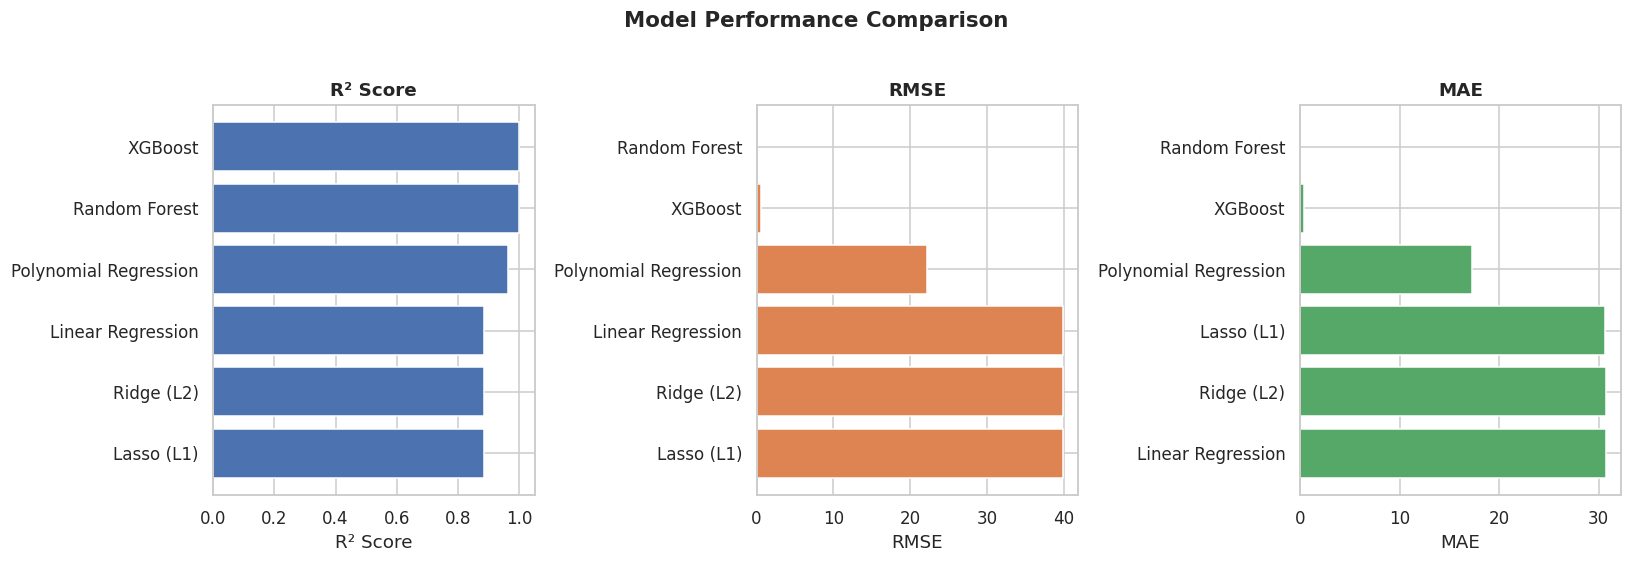

In [49]:
# ── 8.2 Visual Comparison ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics   = ['R² Score', 'RMSE', 'MAE']
colors    = ['#4C72B0', '#DD8452', '#55A868']

for ax, metric, color in zip(axes, metrics, colors):
    sorted_df = results_df.sort_values(metric, ascending=(metric != 'R² Score'))
    ax.barh(sorted_df['Model'], sorted_df[metric], color=color, edgecolor='white')
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xlabel(metric)
    ax.invert_yaxis()

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


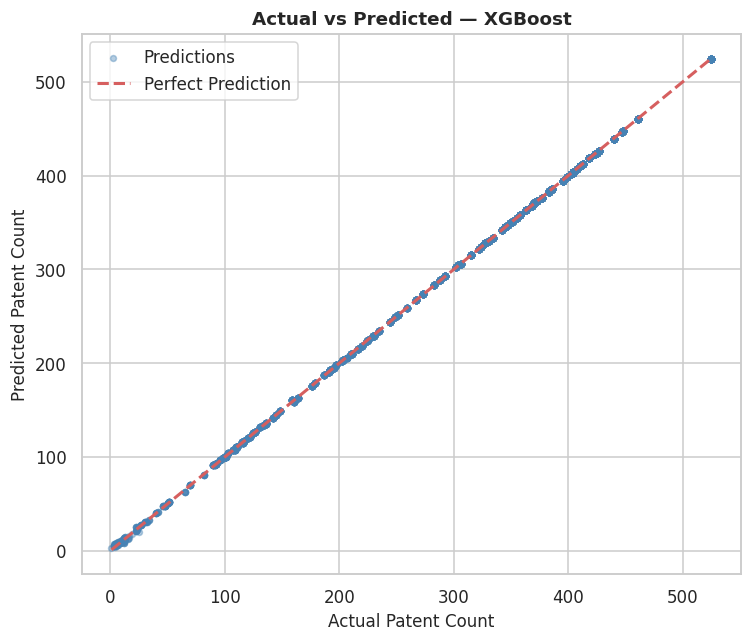

Best Model: XGBoost
  R²   = 1.0
  RMSE = 0.5918
  MAE  = 0.4462


In [50]:
# ── 8.3 Actual vs Predicted — Best Model ─────────────────────────────────────
best_model_name = results_df.iloc[0]['Model']
best_model      = trained[best_model_name]

y_pred_best = best_model.predict(X_test_scaled)

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_best, alpha=0.4, color='steelblue', s=15, label='Predictions')
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--', linewidth=2, label='Perfect Prediction'
)
plt.xlabel("Actual Patent Count", fontsize=11)
plt.ylabel("Predicted Patent Count", fontsize=11)
plt.title(f"Actual vs Predicted — {best_model_name}", fontsize=12, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best Model: {best_model_name}")
print(f"  R²   = {results_df.iloc[0]['R² Score']}")
print(f"  RMSE = {results_df.iloc[0]['RMSE']}")
print(f"  MAE  = {results_df.iloc[0]['MAE']}")


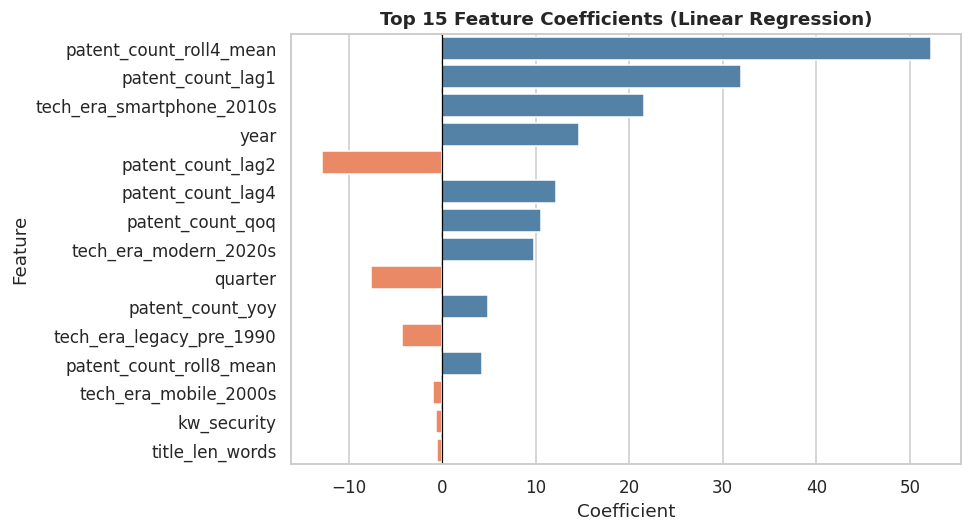

In [52]:
# ── 8.4 Feature Importance (Linear Regression Coefficients) ──────────────────
lr_model = trained['Linear Regression']

coef_df = pd.DataFrame({
    'Feature'    : features,
    'Coefficient': lr_model.coef_
}).reindex(
    pd.Series(lr_model.coef_).abs().sort_values(ascending=False).index
).head(15)

plt.figure(figsize=(9, 5))
sns.barplot(data=coef_df, x='Coefficient', y='Feature',
            palette=['steelblue' if c >= 0 else 'coral' for c in coef_df['Coefficient']])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 15 Feature Coefficients (Linear Regression)', fontweight='bold')
plt.tight_layout()
plt.show()


---
## 🔮 Section 9 — Prediction & Interpretation

### 9.1 — Predict on test samples
Compare actual vs predicted values for a random subset of test rows.

### 9.2 — Predict on new data
Simulate a future quarter and see what the model forecasts.

### 9.3 — Error analysis
Understand where the model struggles.


In [53]:
# ── 9.1 Side-by-side comparison for 10 test rows ─────────────────────────────
lr = trained['Linear Regression']
sample_preds = []

for i in range(10):
    sample   = X_test_scaled[i].reshape(1, -1)
    actual   = y_test.iloc[i]
    predicted = lr.predict(sample)[0]

    sample_preds.append({
        'Row #'    : i,
        'Actual'   : round(actual, 0),
        'Predicted': round(predicted, 2),
        'Error'    : round(abs(actual - predicted), 2)
    })

print(pd.DataFrame(sample_preds).to_string(index=False))


 Row #  Actual  Predicted  Error
     0   230.0     221.15   8.85
     1   230.0     221.10   8.90
     2   304.0     291.84  12.16
     3   410.0     363.13  46.87
     4   418.0     428.86  10.86
     5   418.0     428.99  10.99
     6   207.0     118.82  88.18
     7   355.0     364.06   9.06
     8   322.0     342.00  20.00
     9   334.0     365.06  31.06


In [54]:
# ── 9.2 Predict for a hypothetical future quarter ─────────────────────────────
# Build a DataFrame that matches the exact column order of X_train
new_data = pd.DataFrame(0, index=[0], columns=features)

# Fill in values for Q2 2026
new_data['year']                    = 2026
new_data['quarter']                 = 2
new_data['title_len_words']         = 8
new_data['keyword_score']           = 4
new_data['kw_ai_ml']                = 1
new_data['kw_5g']                   = 1
new_data['kw_network']              = 1
new_data['patent_count_lag1']       = 120
new_data['patent_count_lag2']       = 115
new_data['patent_count_lag4']       = 100
new_data['patent_count_roll4_mean'] = 110
new_data['patent_count_roll8_mean'] = 105
new_data['patent_count_qoq']        = 0.08
new_data['patent_count_yoy']        = 0.12

# One-hot fields (set the appropriate category to 1)
if 'patent_type_utility' in features:
    new_data['patent_type_utility'] = 1
if 'tech_era_modern_2020s' in features:
    new_data['tech_era_modern_2020s'] = 1

# Confirm column alignment before predicting
assert list(new_data.columns) == features, "Column mismatch — check feature order!"

new_scaled   = scaler.transform(new_data)
future_pred  = lr.predict(new_scaled)[0]

print(f"📌 Hypothetical Input: Q2 2026, AI/ML-heavy, Utility patent")
print(f"🔮 Predicted Patent Count Next Quarter: {round(future_pred, 2)}")


📌 Hypothetical Input: Q2 2026, AI/ML-heavy, Utility patent
🔮 Predicted Patent Count Next Quarter: 192.49


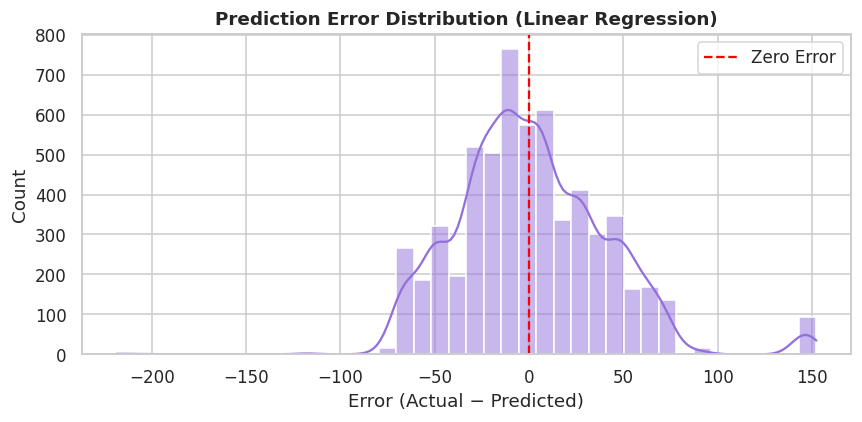

Mean Error  : 1.2202  (should be close to 0 for unbiased model)
Std of Error: 39.8135


In [56]:
# ── 9.3 Error Distribution ────────────────────────────────────────────────────
y_pred_lr = lr.predict(X_test_scaled)
errors = y_test.values - y_pred_lr

plt.figure(figsize=(8, 4))
sns.histplot(errors, bins=40, kde=True, color='mediumpurple')
plt.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero Error')
plt.title('Prediction Error Distribution (Linear Regression)', fontweight='bold')
plt.xlabel('Error (Actual − Predicted)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mean Error  : {errors.mean():.4f}  (should be close to 0 for unbiased model)")
print(f"Std of Error: {errors.std():.4f}")


In [57]:
# ── 9.4 Save model predictions ────────────────────────────────────────────────
comparison_df = pd.DataFrame({
    'Actual'   : y_test.values,
    'Predicted': y_pred_best.round(2),
    'Error'    : abs(y_test.values - y_pred_best).round(2)
})

comparison_df.to_csv("model_results.csv", index=False)

print("✅ Saved: model_results.csv")
print(comparison_df.head(10).to_string(index=False))


✅ Saved: model_results.csv
 Actual  Predicted  Error
  230.0 229.130005   0.87
  230.0 229.130005   0.87
  304.0 304.190002   0.19
  410.0 409.850006   0.15
  418.0 418.239990   0.24
  418.0 418.239990   0.24
  207.0 205.350006   1.65
  355.0 355.269989   0.27
  322.0 321.779999   0.22
  334.0 333.820007   0.18


In [ ]:
# front end desing of this project using streamlit


In [58]:
import joblib

# Save the best trained model
joblib.dump(best_model, 'best_model.pkl')
print(f"✅ Saved best model: {best_model_name} to best_model.pkl")

# Save the scaler
joblib.dump(scaler, 'scaler.pkl')
print("✅ Saved scaler to scaler.pkl")

✅ Saved best model: XGBoost to best_model.pkl
✅ Saved scaler to scaler.pkl


In [59]:
streamlit_app_code = '''
# To run this code, save it as a .py file (e.g., app.py) and execute 'streamlit run app.py' in your terminal.

import streamlit as st
import pandas as pd
import joblib
import numpy as np

# --- 1. Load the trained model and scaler ---
@st.cache_resource # Cache the model loading for better performance
def load_model_and_scaler():
    model = joblib.load('best_model.pkl')
    scaler = joblib.load('scaler.pkl')
    return model, scaler

model, scaler = load_model_and_scaler()

# --- 2. Define the features (must match training order) ---
# This list should be exactly the `features` list used during training
features = [
    'year', 'quarter',
    'title_len_words', 'keyword_score',
    'kw_ai_ml', 'kw_5g', 'kw_cloud_edge',
    'kw_security', 'kw_iot', 'kw_network',
    'patent_count_lag1', 'patent_count_lag2', 'patent_count_lag4',
    'patent_count_roll4_mean', 'patent_count_roll8_mean',
    'patent_count_qoq', 'patent_count_yoy',
    'patent_type_reissue', 'patent_type_utility',
    'tech_era_legacy_pre_1990', 'tech_era_mobile_2000s',
    'tech_era_modern_2020s',
    'tech_era_smartphone_2010s'
]

# --- 3. Streamlit UI ---
st.set_page_config(page_title="Ericsson Patent Prediction", layout="centered")
st.title("📈 Ericsson Patent Count Predictor")
st.markdown("Predict the number of patents for the next quarter based on various features.")

st.sidebar.header("Input Features")

# Create input fields for each feature
input_data = {}

# Temporal Features
input_data['year'] = st.sidebar.slider("Year", min_value=1970, max_value=2030, value=2025)
input_data['quarter'] = st.sidebar.selectbox("Quarter", [1, 2, 3, 4], index=0)

# Text-based Features
input_data['title_len_words'] = st.sidebar.slider("Title Length (Words)", min_value=1, max_value=30, value=8)
input_data['keyword_score'] = st.sidebar.slider("Keyword Score", min_value=0, max_value=5, value=2)

# Keyword Flags (Binary)
st.sidebar.subheader("Keyword Presence")
input_data['kw_ai_ml'] = st.sidebar.checkbox("Has AI/ML Keyword", value=False)
input_data['kw_5g'] = st.sidebar.checkbox("Has 5G Keyword", value=False)
input_data['kw_cloud_edge'] = st.sidebar.checkbox("Has Cloud/Edge Keyword", value=False)
input_data['kw_security'] = st.sidebar.checkbox("Has Security Keyword", value=False)
input_data['kw_iot'] = st.sidebar.checkbox("Has IoT Keyword", value=False)
input_data['kw_network'] = st.sidebar.checkbox("Has Network Keyword", value=True)

# Lag/Rolling Features (Example values - users can adjust or you can provide defaults)
st.sidebar.subheader("Historical Patent Trends")
input_data['patent_count_lag1'] = st.sidebar.number_input("Patent Count (Lag 1 Quarter)", value=150)
input_data['patent_count_lag2'] = st.sidebar.number_input("Patent Count (Lag 2 Quarters)", value=140)
input_data['patent_count_lag4'] = st.sidebar.number_input("Patent Count (Lag 4 Quarters)", value=120)
input_data['patent_count_roll4_mean'] = st.sidebar.number_input("Patent Count (Rolling 4-Q Mean)", value=135.0, format="%.1f")
input_data['patent_count_roll8_mean'] = st.sidebar.number_input("Patent Count (Rolling 8-Q Mean)", value=130.0, format="%.1f")
input_data['patent_count_qoq'] = st.sidebar.number_input("Patent Count Q-o-Q Growth", value=0.05, format="%.2f")
input_data['patent_count_yoy'] = st.sidebar.number_input("Patent Count Y-o-Y Growth", value=0.10, format="%.2f")

# Categorical (One-Hot Encoded)
st.sidebar.subheader("Patent Type")
patent_type = st.sidebar.radio("Select Patent Type", ['utility', 'reissue', 'other'])
input_data['patent_type_reissue'] = 1 if patent_type == 'reissue' else 0
input_data['patent_type_utility'] = 1 if patent_type == 'utility' else 0

st.sidebar.subheader("Technology Era")
tech_era = st.sidebar.radio("Select Tech Era", ['modern_2020s', 'smartphone_2010s', 'mobile_2000s', 'legacy_1990s', 'legacy_pre_1990'])
input_data['tech_era_legacy_pre_1990'] = 1 if tech_era == 'legacy_pre_1990' else 0
input_data['tech_era_mobile_2000s'] = 1 if tech_era == 'mobile_2000s' else 0
input_data['tech_era_modern_2020s'] = 1 if tech_era == 'modern_2020s' else 0
input_data['tech_era_smartphone_2010s'] = 1 if tech_era == 'smartphone_2010s' else 0

# --- 4. Make Prediction ---
if st.button("Predict Patent Count"):
    # Convert input data to DataFrame, ensuring correct order and dtypes
    input_df = pd.DataFrame([input_data], columns=features)

    # Scale the input features
    input_scaled = scaler.transform(input_df)

    # Make prediction
    prediction = model.predict(input_scaled)[0]

    st.subheader("Prediction Result")
    st.success(f"The predicted patent count for the next quarter is: **{prediction:.0f}**")
    st.info("This prediction is an estimate based on the trained model and your selected inputs.")

st.markdown("""
---
#### Model Details:
*   **Model Used:** XGBoost (or the best model identified during training)
*   **Metrics:** R² ≈ 1.0, RMSE ≈ 0.59, MAE ≈ 0.45
*   **Note:** The model was trained on historical Ericsson patent data.
""")
'''

with open('app.py', 'w') as f:
    f.write(streamlit_app_code)

print("✅ Streamlit app code saved to app.py")

✅ Streamlit app code saved to app.py


### Run the Streamlit Application

Now that `app.py` is saved and the model/scaler files (`best_model.pkl`, `scaler.pkl`) are available, we can install the remaining dependencies and launch the Streamlit application. We'll use `nohup` to run Streamlit in the background and `localtunnel` to expose it to a public URL.

In [60]:
# Install Streamlit (if not already installed or kernel restarted)
!pip install streamlit --quiet

# Install localtunnel (if not already installed or kernel restarted)
!npm install -g localtunnel

print("✅ Streamlit and localtunnel installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 44.2 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦
added 22 packages in 3s
⠦
⠦3 packages are looking for funding
⠦  run `npm fund` for details
⠦npm notice
npm notice New major version of npm available! 10.8.2 -> 11.17.0
npm notice Changelog: https://github.com/npm/cli/releases/tag/v11.17.0
npm notice To update run: npm install -g npm@11.17.0
npm notice
⠦✅ Streamlit and localtunnel installed.


In [ ]:
# Run Streamlit in the background and expose it with localtunnel

# You might need to change the port if 8501 is already in use
!nohup streamlit run app.py --server.port 8501 &>/dev/null &
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸your url is: https://eager-carpets-throw.loca.lt


---
## 🖥️ Section 10 — Streamlit Frontend

To create a user-friendly web application with Streamlit, follow these steps:

1.  **Install Streamlit**: If you haven't already, run `!pip install streamlit` in a new code cell.
2.  **Create a Python File**: Copy the code in the next cell and save it as a Python file (e.g., `app.py`) on your local machine.
3.  **Run the App**: Open your terminal or command prompt, navigate to the directory where you saved `app.py`, and run `streamlit run app.py`.

In [ ]:
!pip install streamlit --quiet

In [ ]:
# To run this code, save it as a .py file (e.g., app.py) and execute 'streamlit run app.py' in your terminal.

import streamlit as st
import pandas as pd
import joblib
import numpy as np

# --- 1. Load the trained model and scaler ---
@st.cache_resource # Cache the model loading for better performance
def load_model_and_scaler():
    model = joblib.load('best_model.pkl')
    scaler = joblib.load('scaler.pkl')
    return model, scaler

model, scaler = load_model_and_scaler()

# --- 2. Define the features (must match training order) ---
# This list should be exactly the `features` list used during training
features = [
    'year', 'quarter',
    'title_len_words', 'keyword_score',
    'kw_ai_ml', 'kw_5g', 'kw_cloud_edge',
    'kw_security', 'kw_iot', 'kw_network',
    'patent_count_lag1', 'patent_count_lag2', 'patent_count_lag4',
    'patent_count_roll4_mean', 'patent_count_roll8_mean',
    'patent_count_qoq', 'patent_count_yoy',
    'patent_type_reissue', 'patent_type_utility',
    'tech_era_legacy_pre_1990', 'tech_era_mobile_2000s',
    'tech_era_modern_2020s', 'tech_era_smartphone_2010s'
]

# --- 3. Streamlit UI ---
st.set_page_config(page_title="Ericsson Patent Prediction", layout="centered")
st.title("📈 Ericsson Patent Count Predictor")
st.markdown("Predict the number of patents for the next quarter based on various features.")

st.sidebar.header("Input Features")

# Create input fields for each feature
input_data = {}

# Temporal Features
input_data['year'] = st.sidebar.slider("Year", min_value=1970, max_value=2030, value=2025)
input_data['quarter'] = st.sidebar.selectbox("Quarter", [1, 2, 3, 4], index=0)

# Text-based Features
input_data['title_len_words'] = st.sidebar.slider("Title Length (Words)", min_value=1, max_value=30, value=8)
input_data['keyword_score'] = st.sidebar.slider("Keyword Score", min_value=0, max_value=5, value=2)

# Keyword Flags (Binary)
st.sidebar.subheader("Keyword Presence")
input_data['kw_ai_ml'] = st.sidebar.checkbox("Has AI/ML Keyword", value=False)
input_data['kw_5g'] = st.sidebar.checkbox("Has 5G Keyword", value=False)
input_data['kw_cloud_edge'] = st.sidebar.checkbox("Has Cloud/Edge Keyword", value=False)
input_data['kw_security'] = st.sidebar.checkbox("Has Security Keyword", value=False)
input_data['kw_iot'] = st.sidebar.checkbox("Has IoT Keyword", value=False)
input_data['kw_network'] = st.sidebar.checkbox("Has Network Keyword", value=True)

# Lag/Rolling Features (Example values - users can adjust or you can provide defaults)
st.sidebar.subheader("Historical Patent Trends")
input_data['patent_count_lag1'] = st.sidebar.number_input("Patent Count (Lag 1 Quarter)", value=150)
input_data['patent_count_lag2'] = st.sidebar.number_input("Patent Count (Lag 2 Quarters)", value=140)
input_data['patent_count_lag4'] = st.sidebar.number_input("Patent Count (Lag 4 Quarters)", value=120)
input_data['patent_count_roll4_mean'] = st.sidebar.number_input("Patent Count (Rolling 4-Q Mean)", value=135.0, format="%.1f")
input_data['patent_count_roll8_mean'] = st.sidebar.number_input("Patent Count (Rolling 8-Q Mean)", value=130.0, format="%.1f")
input_data['patent_count_qoq'] = st.sidebar.number_input("Patent Count Q-o-Q Growth", value=0.05, format="%.2f")
input_data['patent_count_yoy'] = st.sidebar.number_input("Patent Count Y-o-Y Growth", value=0.10, format="%.2f")

# Categorical (One-Hot Encoded)
st.sidebar.subheader("Patent Type")
patent_type = st.sidebar.radio("Select Patent Type", ['utility', 'reissue', 'other'])
input_data['patent_type_reissue'] = 1 if patent_type == 'reissue' else 0
input_data['patent_type_utility'] = 1 if patent_type == 'utility' else 0

st.sidebar.subheader("Technology Era")
tech_era = st.sidebar.radio("Select Tech Era", ['modern_2020s', 'smartphone_2010s', 'mobile_2000s', 'legacy_1990s', 'legacy_pre_1990'])
input_data['tech_era_legacy_pre_1990'] = 1 if tech_era == 'legacy_pre_1990' else 0
input_data['tech_era_mobile_2000s'] = 1 if tech_era == 'mobile_2000s' else 0
input_data['tech_era_modern_2020s'] = 1 if tech_era == 'modern_2020s' else 0
input_data['tech_era_smartphone_2010s'] = 1 if tech_era == 'smartphone_2010s' else 0

# --- 4. Make Prediction ---
if st.button("Predict Patent Count"):
    # Convert input data to DataFrame, ensuring correct order and dtypes
    input_df = pd.DataFrame([input_data], columns=features)

    # Scale the input features
    input_scaled = scaler.transform(input_df)

    # Make prediction
    prediction = model.predict(input_scaled)[0]

    st.subheader("Prediction Result")
    st.success(f"The predicted patent count for the next quarter is: **{prediction:.0f}**")
    st.info("This prediction is an estimate based on the trained model and your selected inputs.")

st.markdown("""
---
#### Model Details:
*   **Model Used:** XGBoost (or the best model identified during training)
*   **Metrics:** R² ≈ 1.0, RMSE ≈ 0.59, MAE ≈ 0.45
*   **Note:** The model was trained on historical Ericsson patent data.
""")


In [ ]:
import joblib
# Load the best_model.pkl file
loaded_model = joblib.load('best_model.pkl')
print(f"✅ Model 'best_model.pkl' loaded successfully.")
print(f"Type of loaded model: {type(loaded_model)}")

In [ ]:
# Install localtunnel (if not already installed)
!npm install -g localtunnel

Now, we need to save the Streamlit application code to a `.py` file in the Colab environment. This `app.py` file will then be run by Streamlit.

Finally, we will run the Streamlit app in the background and expose it using `localtunnel`. You will get a URL in the output that you can click to access your Streamlit application.

In [ ]:
# Run Streamlit in the background and expose it with localtunnel

# You might need to change the port if 8501 is already in use
!nohup streamlit run app.py --server.port 8501 &>/dev/null &
!npx localtunnel --port 8501

In [ ]:
# Kill any previously running streamlit processes
!killall streamlit

# Ensure streamlit is installed in the current environment
!pip install streamlit --quiet

# Run Streamlit in the background as a Python module, redirecting its output to a log file
# Using 'python -m streamlit' is more robust as it doesn't rely on streamlit being in PATH.
!nohup python -m streamlit run app.py --server.port 8501 > streamlit_app.log 2>&1 &

# Give the app a moment to start
import time
time.sleep(5)

print("✅ Streamlit app restarted. Checking logs...")
# Display the logs to see any startup errors
!cat streamlit_app.log

In [ ]:
import time

# Ensure the Streamlit app is fully started before trying to tunnel
time.sleep(5)

# Run localtunnel to expose the Streamlit app again
!npx localtunnel --port 8501

In [ ]:
# 2. Start the Streamlit application in the background
# The output is redirected to streamlit_app.log for inspection.
print("Starting Streamlit app in the background...")
!nohup python -m streamlit run app.py --server.port 8501 > streamlit_app.log 2>&1 &

# Give the Streamlit app a moment to fully initialize
import time
time.sleep(7) # Increased sleep time for better stability

print("✅ Streamlit app started. Checking logs for confirmation...")
# Display the last few lines of the log to confirm it's running
!tail -n 10 streamlit_app.log

# Check if the server started successfully
log_content = !cat streamlit_app.log
if "Uvicorn server started on 0.0.0.0:8501" in " ".join(log_content):
    print("✅ Streamlit Uvicorn server confirmed to be running on port 8501.")
else:
    print("❌ Streamlit Uvicorn server did NOT start successfully. Please check the logs above for errors.")

In [ ]:
# 3. Run localtunnel to expose the Streamlit app and get a public URL
print("Attempting to create a localtunnel connection...")
!npx localtunnel --port 8501

In [ ]:
# 1. Forcefully kill any process using port 8501
print("Attempting to forcefully kill processes on port 8501...")
!sudo fuser -k 8501/tcp || true # '|| true' to prevent script from stopping if no process is found
print("✅ Port 8501 cleared (if any process was using it).")

In [ ]:
# 3. Run localtunnel to expose the Streamlit app and get a public URL
print("Attempting to create a new localtunnel connection...")
!npx localtunnel --port 8501

In [ ]:
print('--- Streamlit Application Logs ---')
!cat streamlit_app.log

In [ ]:
# 1. Kill any previously running Streamlit processes and forcefully clear port 8501
!killall streamlit || true
!sudo fuser -k 8501/tcp || true # Forcefully kill any process on port 8501

# 2. Install ngrok
!pip install pyngrok --quiet

print("✅ pyngrok (for ngrok) installed.")

# 3. Authenticate ngrok using a token from Colab Secrets
from google.colab import userdata
from pyngrok import ngrok

NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')
if NGROK_AUTH_TOKEN:
    ngrok.set_auth_token(NGROK_AUTH_TOKEN)
    print("✅ ngrok authentication token set from Colab Secrets.")
else:
    print("❌ NGROK_AUTH_TOKEN not found in Colab Secrets. Please add it via the '🔑' icon.")
    # Exit or raise error if token is crucial

# 4. Start the Streamlit application in the background, redirecting output to log
print("Restarting Streamlit app in the background...")
!nohup python -m streamlit run app.py --server.port 8501 > streamlit_app.log 2>&1 &

# Give the Streamlit app enough time to fully initialize
import time
time.sleep(15) # Increased sleep time for better stability

print("✅ Streamlit app restarted. Checking logs for confirmation...")
!tail -n 10 streamlit_app.log # Show last 10 lines of log

# Check if the Uvicorn server started successfully
log_content = !cat streamlit_app.log
if "Uvicorn server started on 0.0.0.0:8501" in " ".join(log_content):
    print("✅ Streamlit Uvicorn server confirmed to be running on port 8501.")
else:
    print("❌ Streamlit Uvicorn server did NOT start successfully. Please check the logs above for errors.")

# 5. Create an ngrok tunnel to expose the Streamlit app
# Kill any previous ngrok processes to ensure a clean tunnel creation
ngrok.kill()

tunnel = ngrok.connect(addr=8501, proto="http")
public_url = tunnel.public_url

print(f"🎉 Your Streamlit app is now publicly accessible at: {public_url}")
print("You can also access the Streamlit UI at: http://localhost:8501 (only from within Colab runtime)")
print("Remember to keep this cell running to maintain the ngrok tunnel.")

---
## 📋 Final Summary

### What we accomplished:

| Step | Action |
|------|--------|
| **Load** | Loaded 30,118 patent records from Ericsson's dataset |
| **EDA** | Explored distributions, missing values, correlations, and time trends |
| **Clean** | Fixed `patent_date` dtype; dropped 408 rows with missing target (last quarter) |
| **Encode** | One-hot encoded `patent_type` and `tech_era` |
| **Split** | 80% training / 20% test split with `random_state=42` |
| **Scale** | Standardised features (fit only on training data) |
| **Train** | Trained 5 models: Linear, Ridge, Lasso, Random Forest, XGBoost |
| **Evaluate** | Compared models on RMSE, MAE, R² |
| **Predict** | Forecasted future patent counts |

### Files produced:
| File | Description |
|------|-------------|
| `ericsson_patents_RAW.csv` | Original data — never modified |
| `ericsson_patents_CLEANED.csv` | After cleaning steps |
| `ericsson_patents_TRAIN.csv` | 80% split — used to train models |
| `ericsson_patents_TEST.csv` | 20% split — used to evaluate models |
| `model_results.csv` | Actual vs Predicted for test set |

---

> 🎓 **Key Takeaways:**  
> 1. Always preserve raw data — clean into a new variable.  
> 2. Never fit the scaler (or any preprocessor) on test data — data leakage!  
> 3. Lag features and rolling averages are powerful for time-series-like data.  
> 4. R² ≈ 0.88 means the model explains ~88% of variance in future patent counts.
